In [2]:
import pandas as pd
import numpy as np

In [3]:
car_sales = pd.read_csv(r"C:\Users\ajays\OneDrive\Desktop\UMD Classes and Resources\BUDT 730 - Data models\BUDT 730 - Project\car_prices_clean_main.csv")

In [4]:
car_sales.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,saledate_clean
0,2001,HUMMER,H1,Wagon,Suv,Automatic,137za84341e193591,ca,21,65612,blue,gray,auto city sales/leasing,43400,45750,Thu May 28 2015 05:00:00 GMT-0700 (PDT),2015-05-28
1,1999,Acura,Tl,3.2,Sedan,Automatic,19uua5640xa034760,ga,19,233154,black,tan,enterprise vehicle exchange / tra / rental / t...,1075,1050,Wed Feb 11 2015 16:00:00 GMT-0800 (PST),2015-02-11
2,1999,Acura,Tl,3.2,Sedan,Automatic,19uua5640xa053244,fl,25,175516,blue,beige,coggin nissan,1325,2100,Thu Feb 05 2015 08:20:00 GMT-0800 (PST),2015-02-05
3,1999,Acura,Tl,3.2,Sedan,Automatic,19uua5640xa053826,oh,35,113958,red,black,bargain wheels llc,1825,1600,Thu Dec 18 2014 10:05:00 GMT-0800 (PST),2014-12-18
4,1999,Acura,Tl,3.2,Sedan,Automatic,19uua5641xa040227,va,2,130002,green,tan,purple heart,1975,2800,Thu Mar 05 2015 03:50:00 GMT-0800 (PST),2015-03-05


In [9]:
car_sales.describe()

,year,condition,odometer,mmr,sellingprice
count,536433.000000,536433.000000,536433.000000,536433.000000,536433.000000
mean,2010.146262,30.888961,67253.802443,13866.636560,13707.906262
std,3.893405,13.256635,52832.770737,9610.701369,9679.060669
min,1990.000000,1.000000,1.000000,25.000000,1.000000
25%,2008.000000,24.000000,27974.000000,7325.000000,7100.000000
50%,2012.000000,35.000000,50968.000000,12350.000000,12250.000000
75%,2013.000000,41.000000,97608.000000,18400.000000,18300.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [10]:
car_sales['salesDifference'] = car_sales['sellingprice'] - car_sales['mmr']

In [11]:
car_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536433 entries, 0 to 536432
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   year             536433 non-null  int64 
 1   make             536433 non-null  object
 2   model            536433 non-null  object
 3   trim             536433 non-null  object
 4   body             536433 non-null  object
 5   transmission     536433 non-null  object
 6   vin              536433 non-null  object
 7   state            536433 non-null  object
 8   condition        536433 non-null  int64 
 9   odometer         536433 non-null  int64 
 10  color            536433 non-null  object
 11  interior         536433 non-null  object
 12  seller           536433 non-null  object
 13  mmr              536433 non-null  int64 
 14  sellingprice     536433 non-null  int64 
 15  saledate         536433 non-null  object
 16  saledate_clean   536433 non-null  object
 17  salesDiffe

In [36]:
car_sales.describe()

,year,condition,odometer,mmr,sellingprice,salesDifference
count,536433.000000,536433.000000,536433.000000,536433.000000,536433.000000,536433.000000
mean,2010.146262,30.888961,67253.802443,13866.636560,13707.906262,-158.730298
std,3.893405,13.256635,52832.770737,9610.701369,9679.060669,1741.067184
min,1990.000000,1.000000,1.000000,25.000000,1.000000,-87750.000000
25%,2008.000000,24.000000,27974.000000,7325.000000,7100.000000,-800.000000
50%,2012.000000,35.000000,50968.000000,12350.000000,12250.000000,-50.000000
75%,2013.000000,41.000000,97608.000000,18400.000000,18300.000000,650.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,207200.000000


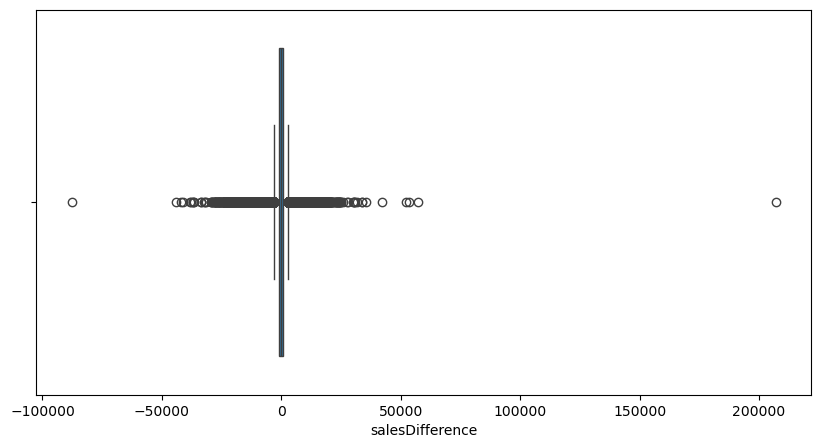

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x=car_sales['salesDifference'])
plt.show()


In [26]:
Q1 = car_sales['salesDifference'].quantile(0.25)
Q3 = car_sales['salesDifference'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

car_stats_Quartile = car_sales[(car_sales['salesDifference'] >= lower_bound) & 
            (car_sales['salesDifference'] <= upper_bound)]
print(car_sales.shape, car_stats_Quartile.shape)


(536433, 18) (503110, 18)


In [27]:
lower_cap = car_stats_Quartile['salesDifference'].quantile(0.01)
upper_cap = car_stats_Quartile['salesDifference'].quantile(0.99)

car_stats_Quartile['salesDifference'] = car_stats_Quartile['salesDifference'].clip(lower_cap, upper_cap)


C:\Users\ajays\AppData\Local\Temp\ipykernel_16992\2974399663.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car_stats_Quartile['salesDifference'] = car_stats_Quartile['salesDifference'].clip(lower_cap, upper_cap)


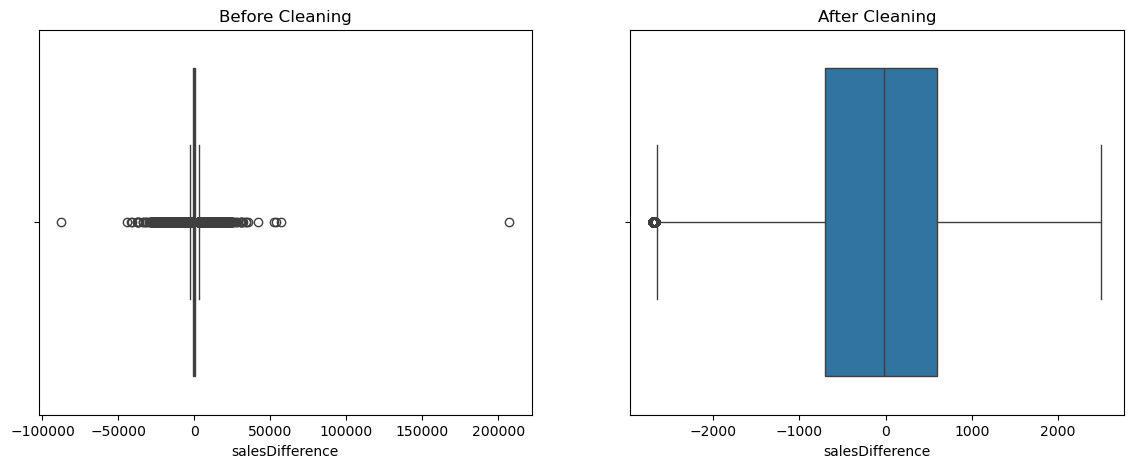

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x=car_sales['salesDifference'], ax=ax[0])
ax[0].set_title("Before Cleaning")

sns.boxplot(x=car_stats_Quartile['salesDifference'], ax=ax[1])
ax[1].set_title("After Cleaning")

plt.show()


In [30]:
car_sales.describe()

,year,condition,odometer,mmr,sellingprice,salesDifference
count,536433.000000,536433.000000,536433.000000,536433.000000,536433.000000,536433.000000
mean,2010.146262,30.888961,67253.802443,13866.636560,13707.906262,-158.730298
std,3.893405,13.256635,52832.770737,9610.701369,9679.060669,1741.067184
min,1990.000000,1.000000,1.000000,25.000000,1.000000,-87750.000000
25%,2008.000000,24.000000,27974.000000,7325.000000,7100.000000,-800.000000
50%,2012.000000,35.000000,50968.000000,12350.000000,12250.000000,-50.000000
75%,2013.000000,41.000000,97608.000000,18400.000000,18300.000000,650.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000,207200.000000


In [29]:
car_stats_Quartile.describe()

,year,condition,odometer,mmr,sellingprice,salesDifference
count,503110.000000,503110.000000,503110.000000,503110.000000,503110.000000,503110.000000
mean,2010.088126,31.214583,68227.995442,13426.114070,13376.420320,-49.915855
std,3.931794,12.997754,52906.964345,9059.822551,9124.905015,1068.442540
min,1990.000000,1.000000,1.000000,25.000000,1.000000,-2700.000000
25%,2008.000000,25.000000,28652.000000,7000.000000,7000.000000,-700.000000
50%,2012.000000,35.000000,51958.500000,12150.000000,12100.000000,-25.000000
75%,2013.000000,42.000000,98990.000000,17950.000000,18000.000000,600.000000
max,2015.000000,49.000000,999999.000000,182000.000000,183000.000000,2500.000000


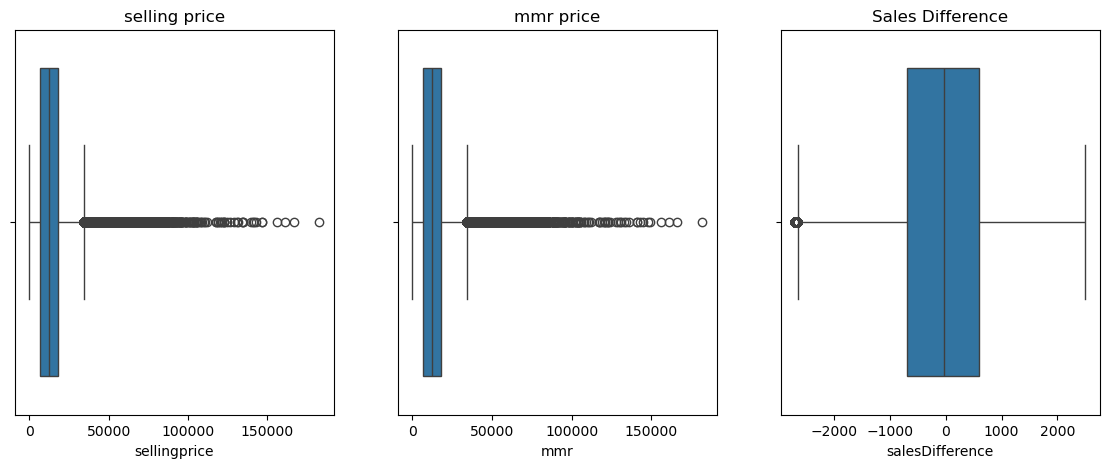

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(14,5))

sns.boxplot(x=car_stats_Quartile['sellingprice'], ax=ax[0])
ax[0].set_title("selling price")

sns.boxplot(x=car_stats_Quartile['mmr'], ax=ax[1])
ax[1].set_title("mmr price")

sns.boxplot(x=car_stats_Quartile['salesDifference'], ax=ax[2])
ax[2].set_title("Sales Difference")

plt.show()

In [35]:
car_stats_Quartile['salesDifference'].skew()


-0.10031808657851589